# Kruskal-Wallis Test

**Module 5: Numerical Outcomes** | Lean Six Sigma Data Analytics

---

## When to Use Kruskal-Wallis

The Kruskal-Wallis test is an **alternative to ANOVA**.

It is used to analyze the relationship between:
- A **numerical** CTQ (Y)
- A **categorical** influence factor (X)

### Non-Parametric Test

Kruskal-Wallis is a **non-parametric** test. This means there is no specific distribution assumed on the residuals.

| Test | Assumption |
|------|------------|
| ANOVA | Residuals are normally distributed, no outliers |
| Kruskal-Wallis | No distribution assumption |

**Trade-off:** If you let go of assumptions, the Kruskal-Wallis test will be **less powerful** than ANOVA. This means you basically need **more data** to show the same difference.

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, probplot
from statsmodels.formula.api import ols

# --- Minitab-style house style -------------------------------------------
import sys
from pathlib import Path as _Path

# minitab_style.py lives in the parent folder of each module directory
sys.path.append(str(_Path.cwd().parent))
import minitab_style as ms

ms.apply_style()

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)

print('Ready for Kruskal-Wallis analysis!')


Ready for Kruskal-Wallis analysis!


---

## Example: Call Center Training

### The Scenario

Consider a call center. Some employees received a training while others did not.

**Question:** Does training have any effect on the total handling time (the total time it takes an employee to handle an incoming call)?

### Identify Your Variables

| Variable | Description | Type |
|----------|-------------|------|
| **Y** | Total Handling Time | Numerical |
| **X** | Training (yes/no) | Categorical |

The tree diagram tells us to analyze this relationship using **ANOVA**.

In [2]:
# Load THT (Total Handling Time) data
def load_tht():
    df = pd.read_excel(xlsx, sheet_name='THT', skiprows=8, header=0, usecols=[0, 1])
    df.columns = ['THT', 'Training']
    return df.dropna()

tht = load_tht()

print('CALL CENTER DATA')
print('=' * 50)
print(f'Total observations: {len(tht)}')
print(f'Employees with training: {sum(tht["Training"] == "Yes")}')
print(f'Employees without training: {sum(tht["Training"] == "No")}')
print()
tht.head(10)

CALL CENTER DATA
Total observations: 56
Employees with training: 21
Employees without training: 35



,THT,Training
0,332,No
1,778,No
2,361,No
3,794,No
4,231,No
5,375,No
6,841,No
7,596,No
8,124,No
9,224,No


---

## Step 1: Try ANOVA First

Following our standard process, we first perform ANOVA and check the assumptions with the **four-in-one plot**.

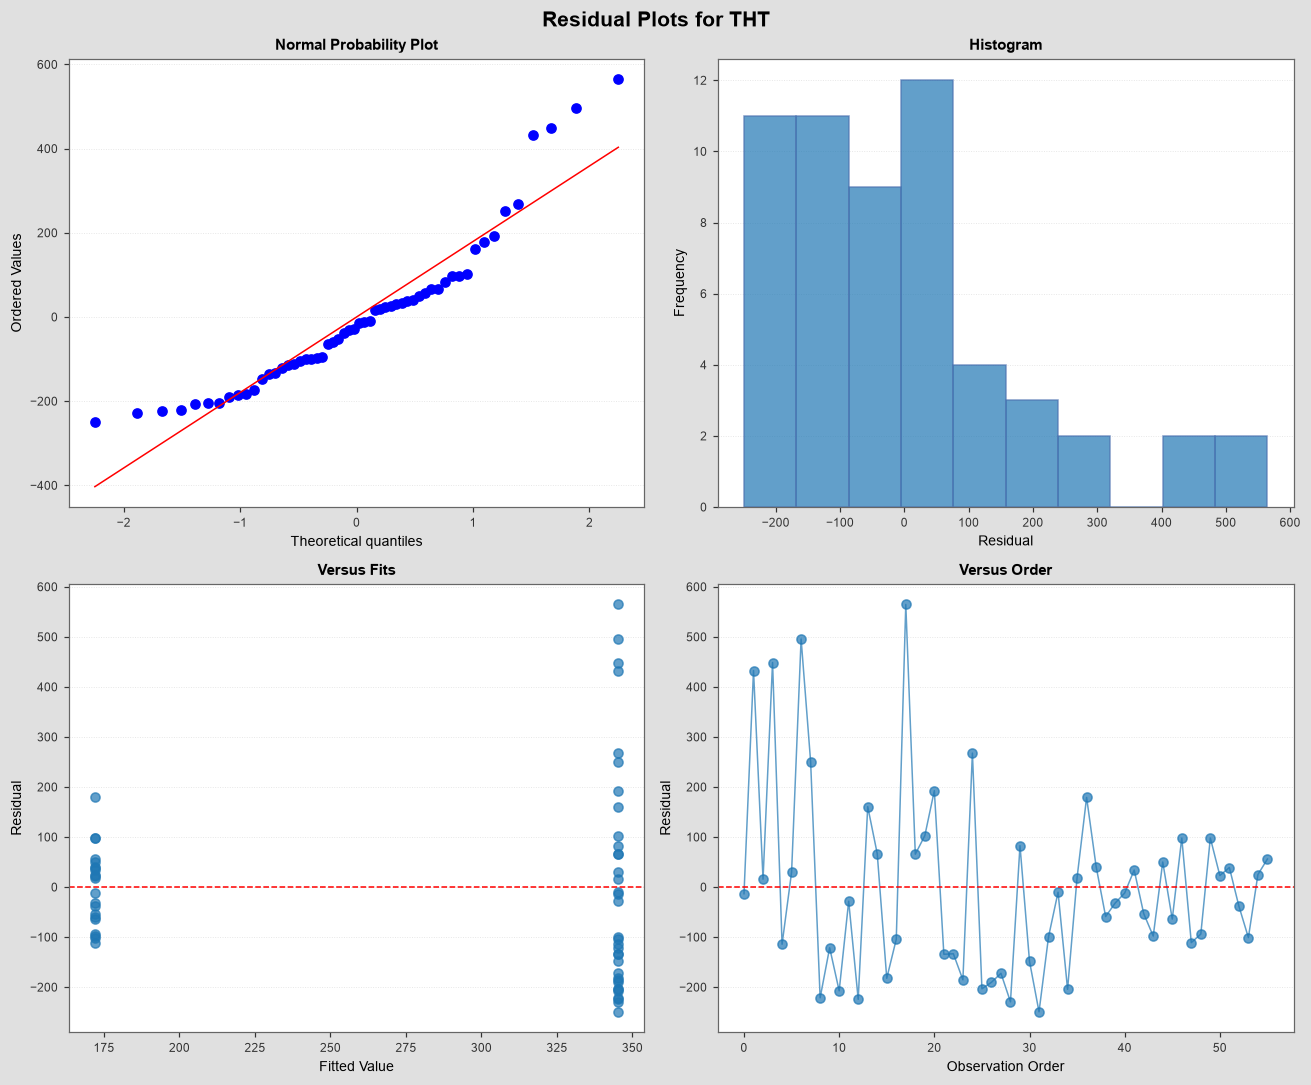

RESIDUAL ANALYSIS

Problem 1: Residuals are NOT normally distributed
  (Points deviate from the line in probability plot)

Problem 2: Time graph shows irregularities

CONCLUSION: ANOVA assumptions are violated.
            We need to apply an alternative technique.
            --> Use Kruskal-Wallis test


In [3]:
# Perform ANOVA and check residuals
model = ols('THT ~ C(Training)', data=tht).fit()
residuals = model.resid

# Four-in-one plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Normal probability plot
probplot(residuals, dist='norm', plot=axes[0, 0])
axes[0, 0].set_title('Normal Probability Plot')

# Histogram
axes[0, 1].hist(residuals, bins=10, edgecolor=ms.HIST_EDGE, alpha=0.7)
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Histogram')

# Residuals vs Fitted
axes[1, 0].scatter(model.fittedvalues, residuals, alpha=0.7)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Fitted Value')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Versus Fits')

# Residuals vs Order (time graph)
axes[1, 1].plot(range(len(residuals)), residuals, 'o-', alpha=0.7)
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_xlabel('Observation Order')
axes[1, 1].set_ylabel('Residual')
axes[1, 1].set_title('Versus Order')

plt.suptitle('Residual Plots for THT', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('RESIDUAL ANALYSIS')
print('=' * 50)
print()
print('Problem 1: Residuals are NOT normally distributed')
print('  (Points deviate from the line in probability plot)')
print()
print('Problem 2: Time graph shows irregularities')
print()
print('CONCLUSION: ANOVA assumptions are violated.')
print('            We need to apply an alternative technique.')
print('            --> Use Kruskal-Wallis test')

---

## Step 2: Apply Kruskal-Wallis Test

Since ANOVA assumptions are not met, we apply the Kruskal-Wallis test.

**Minitab path:** Stat > Nonparametrics > Kruskal-Wallis

| Setting | Value |
|---------|-------|
| Response | Total Handling Time |
| Factor | Training |

In [4]:
# Perform Kruskal-Wallis test
# Equivalent to Minitab: Stat > Nonparametrics > Kruskal-Wallis

trained = tht[tht['Training'] == 'Yes']['THT']
untrained = tht[tht['Training'] == 'No']['THT']

stat, p_value = kruskal(untrained, trained)

print('KRUSKAL-WALLIS TEST RESULTS')
print('=' * 60)
print()
print('Kruskal-Wallis Test on THT (sec)')
print()
print(f'{"Training":<12} {"N":>6} {"Median":>10}')
print(f'{"No":<12} {len(untrained):>6} {untrained.median():>10.1f}')
print(f'{"Yes":<12} {len(trained):>6} {trained.median():>10.1f}')
print(f'{"Overall":<12} {len(tht):>6}')
print()
print(f'H = {stat:.2f}    P = {p_value:.3f}')

KRUSKAL-WALLIS TEST RESULTS

Kruskal-Wallis Test on THT (sec)

Training          N     Median
No               35      246.0
Yes              21      191.0
Overall          56

H = 10.12    P = 0.001


---

## Interpreting the Output

The Kruskal-Wallis analysis is based on **medians** (not means).

In [5]:
# Interpretation
median_trained = trained.median()
median_untrained = untrained.median()
difference = median_untrained - median_trained

print('INTERPRETATION')
print('=' * 60)
print()
print('Medians:')
print(f'  Employees WITH training:    {median_trained:.0f} seconds')
print(f'  Employees WITHOUT training: {median_untrained:.0f} seconds')
print()
print(f'Difference: {difference:.0f} seconds (nearly a minute)')
print()
print('People without training took a lot more time to handle')
print('a phone call than people who received the training.')
print()
print(f'P-value: {p_value:.3f}')
print()
if p_value < 0.05:
    print('P-value < 0.05')
    print('The difference in medians is STATISTICALLY SIGNIFICANT.')
    print()
    print(f'CONCLUSION: Training is an effective method to lower')
    print(f'            the total handling time by {difference:.0f} seconds.')
else:
    print('P-value >= 0.05')
    print('No significant difference detected.')

INTERPRETATION

Medians:
  Employees WITH training:    191 seconds
  Employees WITHOUT training: 246 seconds

Difference: 55 seconds (nearly a minute)

People without training took a lot more time to handle
a phone call than people who received the training.

P-value: 0.001

P-value < 0.05
The difference in medians is STATISTICALLY SIGNIFICANT.

CONCLUSION: Training is an effective method to lower
            the total handling time by 55 seconds.


---

## Summary

### When to Use Kruskal-Wallis

Use when the underlying assumptions of ANOVA are **not met**:
- Residuals not normally distributed
- Irregularities (outliers) present

### How to Interpret

1. Look at the **medians** for each group
2. Check the **p-value** to see if the difference is statistically significant